In [1]:
!pip install -q -U bitsandbytes peft accelerate datasets transformers scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 34.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.9/380.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 112.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 59.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.0 requires scipy<1.17,>=1.8, but you have scipy 1.17.0 which is incompatible.


In [2]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model
from datasets import load_dataset
import os
from tqdm import tqdm
import gc

# Setup dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device attivo: {device}")

2026-01-21 11:47:58.365660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768996078.674499      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768996078.765165      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768996079.549012      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768996079.549067      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768996079.549070      55 computation_placer.cc:177] computation placer alr

Device attivo: cuda


In [3]:
# 1. CARICAMENTO DATASET
filename = "/kaggle/input/dpo-dataset-final/dpo_dataset_FILTERED.jsonl"
dataset_path = None
search_dirs = [".", "/kaggle/working"] + [x[0] for x in os.walk("/kaggle/input")]

for path in search_dirs:
    full_path = os.path.join(path, filename)
    if os.path.exists(full_path):
        dataset_path = full_path
        break

if not dataset_path:
    raise FileNotFoundError("Non trovo il file dpo_dataset_FILTERED.jsonl")

print(f" Dataset trovato: {dataset_path}")
dataset = load_dataset("json", data_files=dataset_path, split="train")

# 2. CARICAMENTO MODELLO
MODEL_ID = "HuggingFaceH4/zephyr-7b-beta"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

print(" Carico Zephyr in 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto"
)
model.config.use_cache = False

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right" # Per DPO manuale è spesso più facile gestire right padding

print("Modello caricato.")

 Dataset trovato: /kaggle/input/dpo-dataset-final/dpo_dataset_FILTERED.jsonl


Generating train split: 0 examples [00:00, ? examples/s]

 Carico Zephyr in 4-bit...


config.json:   0%|          | 0.00/638 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Modello caricato.


In [4]:
# 3. APPLICAZIONE LORA
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 13,631,488 || all params: 7,255,363,584 || trainable%: 0.1879


In [5]:
# Funzione per formattare una coppia (Chosen/Rejected)
def process_data(examples):
    # Prompt template (se non è già nel dataset, adattalo)
    # Assumiamo che 'chosen' e 'rejected' siano già stringhe complete o chat
    
    encoded_chosen = tokenizer(examples['chosen'], truncation=True, max_length=512, padding="max_length")
    encoded_rejected = tokenizer(examples['rejected'], truncation=True, max_length=512, padding="max_length")
    
    return {
        'chosen_input_ids': encoded_chosen['input_ids'],
        'chosen_attention_mask': encoded_chosen['attention_mask'],
        'rejected_input_ids': encoded_rejected['input_ids'],
        'rejected_attention_mask': encoded_rejected['attention_mask'],
    }

print(" Tokenizzazione del dataset...")
tokenized_dataset = dataset.map(process_data, batched=True, remove_columns=dataset.column_names)
tokenized_dataset.set_format("torch")

# DataLoader (Batch size 1 per sicurezza memoria)
train_loader = DataLoader(tokenized_dataset, batch_size=1, shuffle=True)
print("DataLoader pronto.")

 Tokenizzazione del dataset...


Map:   0%|          | 0/1801 [00:00<?, ? examples/s]

DataLoader pronto.


In [6]:
def get_log_probs(logits, labels):
    # Calcola log probabilities per i token corretti
    labels = labels[:, 1:].clone()
    logits = logits[:, :-1, :]
    
    # Maschera per ignorare il padding (-100 solitamente, o pad_token_id)
    padding_mask = (labels != tokenizer.pad_token_id)
    
    # Log softmax
    log_probs = F.log_softmax(logits, dim=-1)
    
    # Prendi solo le probabilità dei token reali scelti
    gathered_log_probs = torch.gather(log_probs, -1, labels.unsqueeze(-1)).squeeze(-1)
    
    # Somma delle log probs (solo dove non c'è padding)
    return (gathered_log_probs * padding_mask).sum(dim=-1)

def dpo_loss_fn(policy_chosen_logps, policy_rejected_logps, ref_chosen_logps, ref_rejected_logps, beta=0.1):
    pi_logratios = policy_chosen_logps - policy_rejected_logps
    ref_logratios = ref_chosen_logps - ref_rejected_logps
    
    logits = pi_logratios - ref_logratios
    
    # La formula magica DPO
    losses = -F.logsigmoid(beta * logits)
    return losses.mean()

In [ ]:
# Parametri
EPOCHS = 1
BETA = 0.1
LR = 1e-5
ACCUMULATION_STEPS = 8 

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
model.train()

# Lista per salvare i dati per il grafico
loss_history = []
step_history = []

print("INIZIO TRAINING MANUALE (DPO SENZA TRL)...")

global_step = 0

for epoch in range(EPOCHS):
    total_loss = 0
    optimizer.zero_grad()
    
    # Togliamo la descrizione dinamica da tqdm per non fare confusione
    progress_bar = tqdm(enumerate(train_loader), total=len(train_loader))
    
    for step, batch in progress_bar:
        # Sposta i dati sulla GPU
        c_ids = batch['chosen_input_ids'].to(device)
        c_mask = batch['chosen_attention_mask'].to(device)
        r_ids = batch['rejected_input_ids'].to(device)
        r_mask = batch['rejected_attention_mask'].to(device)
        
        # 1. Forward Pass POLICY
        policy_chosen_logits = model(c_ids, attention_mask=c_mask).logits
        policy_rejected_logits = model(r_ids, attention_mask=r_mask).logits
        
        policy_chosen_logps = get_log_probs(policy_chosen_logits, c_ids)
        policy_rejected_logps = get_log_probs(policy_rejected_logits, r_ids)
        
        # 2. Forward Pass REFERENCE
        with model.disable_adapter():
            with torch.no_grad():
                ref_chosen_logits = model(c_ids, attention_mask=c_mask).logits
                ref_rejected_logits = model(r_ids, attention_mask=r_mask).logits
                
                ref_chosen_logps = get_log_probs(ref_chosen_logits, c_ids)
                ref_rejected_logps = get_log_probs(ref_rejected_logits, r_ids)
        
        # 3. Calcolo LOSS
        loss = dpo_loss_fn(
            policy_chosen_logps, policy_rejected_logps,
            ref_chosen_logps, ref_rejected_logps,
            beta=BETA
        )
        
        # Accumulo gradienti
        loss_val = loss.item() # Salviamo il valore puro
        loss = loss / ACCUMULATION_STEPS
        loss.backward()
        
        if (step + 1) % ACCUMULATION_STEPS == 0:
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1
            
            # --- SALVATAGGIO DATI  ---
            # Salviamo solo ogni volta che facciamo un passo vero dell'optimizer
            loss_history.append(loss_val)
            step_history.append(global_step)
            
            # STAMPA ESPLICITA 
            if global_step % 5 == 0:
                print(f"Step {global_step} | Loss: {loss_val:.4f}")

        total_loss += loss_val
        
        # Aggiorniamo la barra solo col numero dello step
        progress_bar.set_description(f"Processing batch {step}")

    print(f" Epoch {epoch+1} Completata.")

print(" TRAINING COMPLETATO!")

# --- SALVATAGGIO AUTOMATICO DEI GRAFICI ---
print(" Salvataggio dati grafici...")



INIZIO TRAINING MANUALE (DPO SENZA TRL)...


Processing batch 39:   2%|▏         | 40/1801 [04:52<3:34:17,  7.30s/it]

Step 5 | Loss: 0.6533


Processing batch 79:   4%|▍         | 80/1801 [09:44<3:29:26,  7.30s/it]

Step 10 | Loss: 0.5386


...

Processing batch 1799: 100%|█████████▉| 1800/1801 [3:39:05<00:07,  7.31s/it]

Step 225 | Loss: 0.0000


Processing batch 1800: 100%|██████████| 1801/1801 [3:39:12<00:00,  7.30s/it]

 Epoch 1 Completata.
 TRAINING COMPLETATO!
 Salvataggio dati grafici...


NameError: name 'json' is not defined

Grafico salvato come 'training_curve.png'!
Dati salvati in 'training_loss_data.json'!


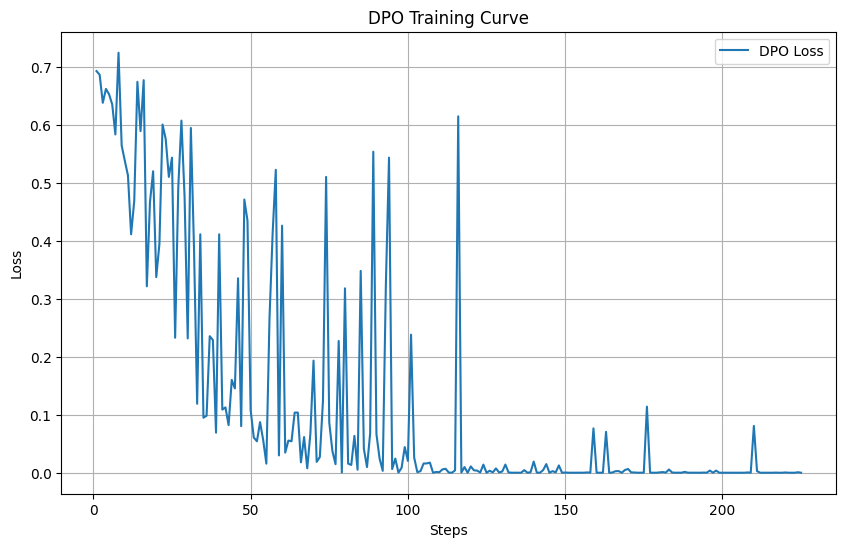

In [8]:
import json
import matplotlib.pyplot as plt
# 1. Salva i numeri grezzi in un file JSON (per sicurezza)
with open("training_loss_data.json", "w") as f:
    json.dump({"steps": step_history, "loss": loss_history}, f)

# 2. Genera il grafico
plt.figure(figsize=(10, 6))
plt.plot(step_history, loss_history, label="DPO Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("DPO Training Curve")
plt.legend()
plt.grid(True)
plt.savefig("training_curve.png")

print("Grafico salvato come 'training_curve.png'!")
print("Dati salvati in 'training_loss_data.json'!")

In [9]:
output_dir = "Zephyr_Manual_DPO_Adapter"
model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)
print(f" Modello salvato in {output_dir}")

 Modello salvato in Zephyr_Manual_DPO_Adapter


In [10]:

import os
from IPython.display import FileLink

# 1. Definiamo cosa zippare (basandoci sul tuo screenshot)
folder_to_zip = "/kaggle/working/Zephyr_Manual_DPO_Adapter"
graph_file = "training_curve.png"
data_file = "training_loss_data.json"
zip_name = "Zephyr_DPO_FINALE_TESI.zip"

print(f"File zippati {zip_name}...")

# 2. Comando zip magico
# -r significa "ricorsivo" (prende tutta la cartella)
!zip -r {zip_name} {folder_to_zip} {graph_file} {data_file}

print("-" * 40)
print("FATTO! Clicca sul link qui sotto per scaricare:")
print("-" * 40)

# 3. Genera il link blu cliccabile
FileLink(zip_name)

File zippati Zephyr_DPO_FINALE_TESI.zip...
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/ (stored 0%)
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/tokenizer_config.json (deflated 68%)
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/adapter_model.safetensors

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


 (deflated 7%)
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/tokenizer.json (deflated 85%)
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/tokenizer.model (deflated 55%)
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/special_tokens_map.json (deflated 70%)
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/adapter_config.json (deflated 57%)
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/chat_template.jinja (deflated 60%)
  adding: kaggle/working/Zephyr_Manual_DPO_Adapter/README.md (deflated 65%)
  adding: training_curve.png (deflated 6%)
  adding: training_loss_data.json (deflated 62%)
----------------------------------------
FATTO! Clicca sul link qui sotto per scaricare:
----------------------------------------


/kaggle/working/Zephyr_DPO_FINALE_TESI.zip